In [61]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
df_frequency = pd.read_csv("data/frequency2.csv")

In [3]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1,0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1,0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1,1.0,35 - 53,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1,0.0,18 - 35,0.0,"€1,000 - €15,076",0.0,14 - 97 inh/km²
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1,0.0,18 - 35,0.0,"€1,000 - €15,076",1.0,97 - 193 inh/km²


In [4]:
df_severity = pd.read_csv("data/severity2.csv")

In [5]:
df_severity.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740,1.0,35 - 53,1.0,"€15,076 - €31,188",2.0,193 - 297 inh/km²
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207,0.0,18 - 35,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803,0.0,18 - 35,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868,1.0,35 - 53,1.0,"€15,076 - €31,188",1.0,97 - 193 inh/km²
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746,1.0,35 - 53,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²


## Frequency Model

In [6]:
formula_freq = "claimNumbMD ~ gender + carType + carCat + job + nYears + age_cluster + carVal_cluster + density_cluster"

In [ ]:
model_freq = smf.glm(
    formula=formula_freq, data=df_frequency, family=sm.families.Poisson()
).fit()

In [8]:
print(model_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24734
Model Family:                 Poisson   Df Model:                           18
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20215.
Date:                Fri, 01 May 2026   Deviance:                       15918.
Time:                        12:28:27   Pearson chi2:                 1.25e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05165
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


so `carCat` doesn't seem to be significant at all. I'm gonna drop it

In [9]:
formula_freq_v2 = "claimNumbMD ~ gender + carType + job + nYears + age_cluster + carVal_cluster + density_cluster"

In [ ]:
model_freq_v2 = smf.glm(
    formula=formula_freq_v2, data=df_frequency, family=sm.families.Poisson()
).fit()

In [11]:
print(model_freq_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24736
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20216.
Date:                Fri, 01 May 2026   Deviance:                       15921.
Time:                        12:28:28   Pearson chi2:                 1.25e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05154
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


the is no significant difference between the car types **A** and **B**

## Severity Model

In [12]:
formula_sev = "claimSizeMD ~ gender + carType + carCat + job + nYears + age_cluster + carVal_cluster + density_cluster"

In [ ]:
model_sev = smf.glm(
    formula=formula_sev,
    data=df_severity,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [14]:
print(model_sev.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12256
Model:                            GLM   Df Residuals:                    12237
Model Family:                   Gamma   Df Model:                           18
Link Function:                    Log   Scale:                          1.0887
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Fri, 01 May 2026   Deviance:                       14703.
Time:                        12:28:28   Pearson chi2:                 1.33e+04
No. Iterations:                    12   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/home/arad/ku-leuven/Statistical-Consulting-Project/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
/home/arad/ku-leuven/Statistical-Consulting-Project/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


In [15]:
(df_severity["claimSizeMD"] == 0).any()

np.True_

there are some zero values for the target in the severity data. we should handle that.
Also dropping the carCat covariate.

In [ ]:
df_severity_clean = df_severity[df_severity["claimSizeMD"] > 0].copy()

In [17]:
formula_sev_v2 = "claimSizeMD ~ gender + carType + job + nYears + age_cluster + carVal_cluster + density_cluster"

In [ ]:
model_sev_v2 = smf.glm(
    formula=formula_sev_v2,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [19]:
print(model_sev_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12235
Model Family:                   Gamma   Df Model:                           16
Link Function:                    Log   Scale:                          1.0878
Method:                          IRLS   Log-Likelihood:                -94671.
Date:                Fri, 01 May 2026   Deviance:                       14423.
Time:                        12:28:29   Pearson chi2:                 1.33e+04
No. Iterations:                    12   Pseudo R-squ. (CS):            0.06870
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


`carVal` doesn't seem to be important in the severity of the claim. dropping this covariate and refitting the model

In [ ]:
formula_sev_final = (
    "claimSizeMD ~ gender + carType + job + nYears + age_cluster + density_cluster"
)

In [ ]:
model_sev_final = smf.glm(
    formula=formula_sev_final,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [22]:
print(model_sev_final.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12237
Model Family:                   Gamma   Df Model:                           14
Link Function:                    Log   Scale:                          1.0909
Method:                          IRLS   Log-Likelihood:                -94674.
Date:                Fri, 01 May 2026   Deviance:                       14426.
Time:                        12:28:29   Pearson chi2:                 1.33e+04
No. Iterations:                    11   Pseudo R-squ. (CS):            0.06832
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## Combining the results

In [ ]:
df_frequency["Expected_Frequency"] = model_freq_v2.predict(df_frequency)

In [ ]:
df_frequency["Expected_Severity"] = model_sev_final.predict(df_frequency)

In [ ]:
df_frequency["Expected_Cost"] = (
    df_frequency["Expected_Frequency"] * df_frequency["Expected_Severity"]
)

In [26]:
df_frequency[["Expected_Frequency", "Expected_Severity", "Expected_Cost"]]

,Expected_Frequency,Expected_Severity,Expected_Cost
0,0.558437,827.201117,461.939850
1,0.618904,746.236809,461.848915
2,0.559855,713.510258,399.462100
3,0.529918,649.245484,344.046568
4,0.547490,738.312130,404.218202
...,...,...,...
24748,0.651755,981.013866,639.380615
24749,0.578698,843.584537,488.180623
24750,0.179067,771.392938,138.131347
24751,0.617161,802.133329,495.045672


In [ ]:
cols_to_show = [
    "gender",
    "age_cluster",
    "carType",
    "job",
    "density_cluster",
    "Expected_Cost",
]

In [28]:
summary_df = df_frequency[cols_to_show].copy()

In [ ]:
summary_df["Expected_Cost"] = summary_df["Expected_Cost"].apply(
    lambda x: f"€{x:,.2f}" if isinstance(x, (int, float)) else x
)

In [30]:
summary_df

,gender,age_cluster,carType,job,density_cluster,Expected_Cost
0,Male,18 - 35,C,Employed,14 - 97 inh/km²,€461.94
1,Male,18 - 35,E,Employed,14 - 97 inh/km²,€461.85
2,Female,35 - 53,E,Unemployed,97 - 193 inh/km²,€399.46
3,Female,18 - 35,C,Housewife,14 - 97 inh/km²,€344.05
4,Female,18 - 35,D,Employed,97 - 193 inh/km²,€404.22
...,...,...,...,...,...,...
24748,Male,18 - 35,D,Unemployed,14 - 97 inh/km²,€639.38
24749,Female,18 - 35,E,Unemployed,14 - 97 inh/km²,€488.18
24750,Female,53 - 75,E,Retired,14 - 97 inh/km²,€138.13
24751,Male,18 - 35,E,Employed,97 - 193 inh/km²,€495.05


## Building the portfolios

In [31]:
features = ["age", "carVal", "density", "gender", "carType", "job"]

In [32]:
df_profile = df_frequency[features].copy()

In [33]:
df_profile.head()

,age,carVal,density,gender,carType,job
0,25,15080,72.012883,Male,C,Employed
1,20,22370,39.550411,Male,E,Employed
2,42,39650,169.529148,Female,E,Unemployed
3,21,12600,58.894688,Female,C,Housewife
4,33,9065,109.631885,Female,D,Employed


In [ ]:
scaler = StandardScaler()
continuous_cols = ["age", "carVal", "density"]
df_profile[continuous_cols] = scaler.fit_transform(df_profile[continuous_cols])

In [ ]:
categorical_cols = ["gender", "carType", "job"]
categorical_indices = [df_profile.columns.get_loc(col) for col in categorical_cols]
categorical_indices

[3, 4, 5]

In [36]:
inertias = []
K_range = range(2, 9)

for k in K_range:
    kproto_test = KPrototypes(n_clusters=k, random_state=7, n_jobs=-1)
    kproto_test.fit(df_profile.values, categorical=categorical_indices)
    inertias.append(kproto_test.cost_)

    print(f"Tested k = {k}, Cost: {kproto_test.cost_:,.0f}")

Tested k = 2, Cost: 76,916
Tested k = 3, Cost: 63,839
Tested k = 4, Cost: 53,295
Tested k = 5, Cost: 49,178
Tested k = 6, Cost: 45,627
Tested k = 7, Cost: 43,473
Tested k = 8, Cost: 41,221


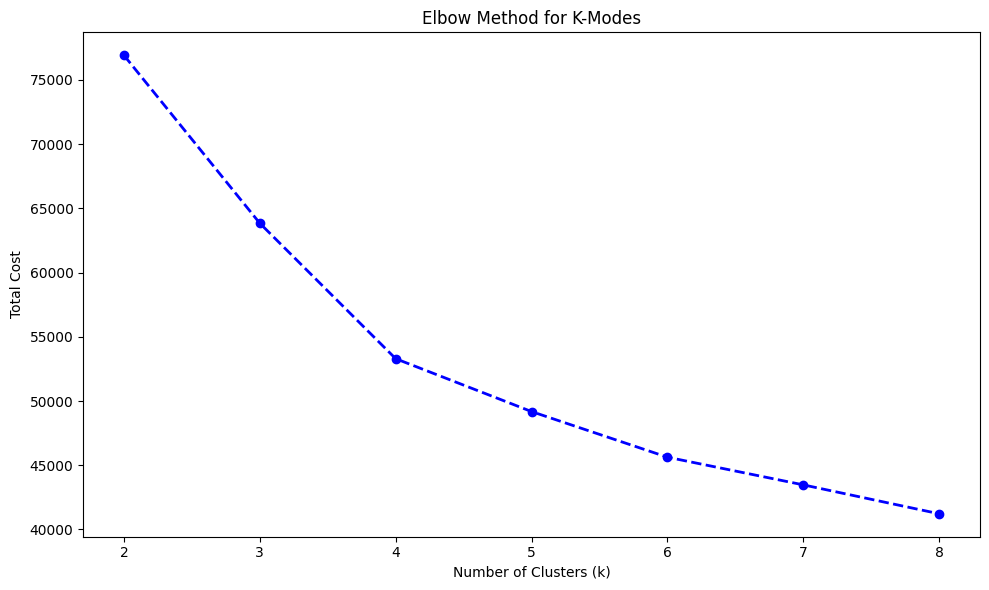

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, marker="o", linestyle="--", color="b", linewidth=2)

ax.set_title("Elbow Method for K-Modes")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Total Cost")

fig.tight_layout()

In [38]:
OPTIMUM_NUM_PERSONA = 4

In [ ]:
features_2 = [
    "gender",
    "carType",
    "job",
    "age_cluster",
    "carVal_cluster",
    "density_cluster",
]
df_profile_2 = df_frequency[features_2].copy()

In [41]:
kmodes = KModes(n_clusters=4, random_state=15, n_jobs=-1)

In [42]:
df_frequency["Persona"] = kmodes.fit_predict(df_profile_2)

In [43]:
persona_summary = (
    df_frequency.groupby("Persona")
    .agg(
        Portfolio_Size=("Persona", "count"),
        Top_Age_Bracket=("age_cluster", lambda x: x.mode()[0]),
        Top_Density=("density_cluster", lambda x: x.mode()[0]),
        Top_Car_Type=("carType", lambda x: x.mode()[0]),
        Top_Job=("job", lambda x: x.mode()[0]),
        Top_Gender=("gender", lambda x: x.mode()[0]),
        Median_Cost=("Expected_Cost", "median"),
    )
    .reset_index()
)

In [45]:
persona_summary["Median_Cost"] = persona_summary["Median_Cost"].apply(
    lambda x: f"€{x:,.2f}"
)

In [48]:
print(persona_summary.to_string(index=False))

 Persona  Portfolio_Size Top_Age_Bracket       Top_Density Top_Car_Type       Top_Job Top_Gender Median_Cost
       0           13614         18 - 35   14 - 97 inh/km²            A      Employed       Male     €429.95
       1            5215         35 - 53  97 - 193 inh/km²            B     Housewife     Female     €312.92
       2            3059         53 - 75 193 - 297 inh/km²            D Self-employed       Male     €364.23
       3            2865         35 - 53   14 - 97 inh/km²            E    Unemployed       Male     €298.53


In [49]:
def map_age(age):
    if age <= 35:
        return "18 - 35"
    elif age <= 53:
        return "35 - 53"
    else:
        return "53 - 75"

In [50]:
def map_carVal(val):
    if val <= 15076:
        return "€1,000 - €15,076"
    elif val <= 31188:
        return "€15,076 - €31,188"
    else:
        return "€31,188 - €49,995"

In [51]:
def map_density(density):
    if density <= 97:
        return "14 - 97 inh/km²"
    elif density <= 193:
        return "97 - 193 inh/km²"
    else:
        return "193 - 297 inh/km²"

In [52]:
raw_data = {
    "age": 28,
    "carVal": 40000,
    "density": 250,
    "gender": "Male",
    "carType": "E",
    "job": "Employed",
}

In [53]:
test_customer = pd.DataFrame(
    [
        {
            "gender": raw_data["gender"],
            "carType": raw_data["carType"],
            "job": raw_data["job"],
            "age_cluster": map_age(raw_data["age"]),
            "carVal_cluster": map_carVal(raw_data["carVal"]),
            "density_cluster": map_density(raw_data["density"]),
        }
    ]
)

In [ ]:
print("1. Raw Input Received:")
for key, value in raw_data.items():
    print(f"   - {key}: {value}")
print("\n")

print("2. Translated Profile for K-Modes:")
print(test_customer.iloc[0].to_string(), "\n")

assigned_persona = kmodes.predict(test_customer)[0]

print(f"Customer mathematically mapped to Persona {assigned_persona}")

1. Raw Input Received:
   - age: 28
   - carVal: 40000
   - density: 250
   - gender: Male
   - carType: E
   - job: Employed


2. Translated Profile for K-Modes:
gender                          Male
carType                            E
job                         Employed
age_cluster                  18 - 35
carVal_cluster     €31,188 - €49,995
density_cluster    193 - 297 inh/km² 

Customer mathematically mapped to Persona 0


## Building the Risk Tier

In [ ]:
premiums = df_frequency[["Expected_Cost"]].copy()

In [ ]:
inertia_values = []
K_range = range(2, 9)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=25)
    kmeans_test.fit(premiums)
    inertia_values.append(kmeans_test.inertia_)

    print(f"Tested k = {k}, Inertia: {kmeans_test.inertia_:,.0f}")

Tested k = 2, Inertia: 398,276,888
Tested k = 3, Inertia: 203,217,364
Tested k = 4, Inertia: 114,409,523
Tested k = 5, Inertia: 77,586,935
Tested k = 6, Inertia: 47,393,642
Tested k = 7, Inertia: 38,752,137
Tested k = 8, Inertia: 29,291,871


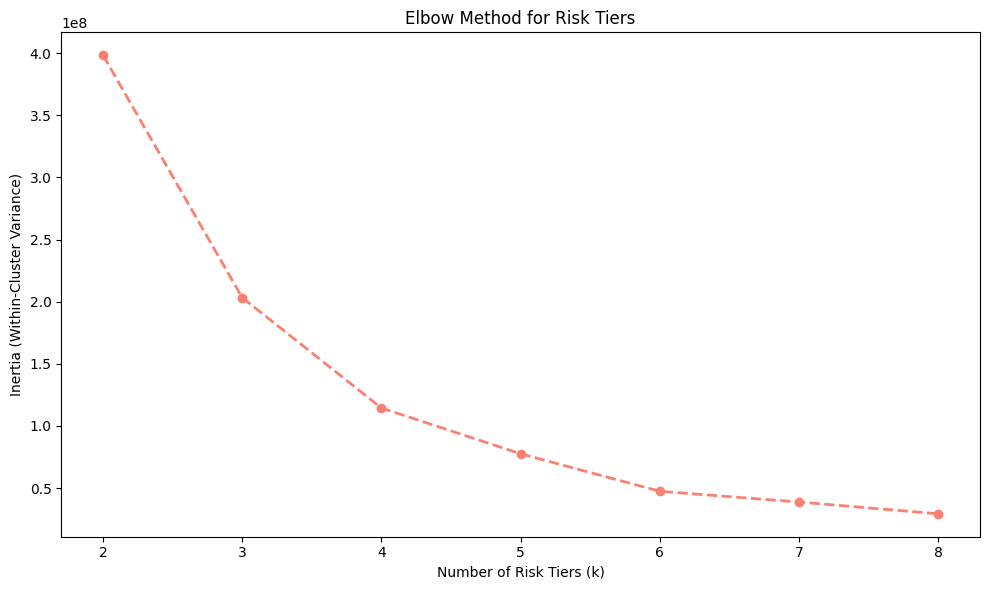

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    K_range, inertia_values, marker="o", linestyle="--", color="salmon", linewidth=2
)
ax.set_title("Elbow Method for Risk Tiers")
ax.set_xlabel("Number of Risk Tiers (k)")
ax.set_ylabel("Inertia (Within-Cluster Variance)")

fig.tight_layout()

In [ ]:
discretizer = KBinsDiscretizer(
    n_bins=3, encode="ordinal", strategy="kmeans", random_state=36
)

In [63]:
binned_premiums = discretizer.fit_transform(premiums)

In [ ]:
risk_labels = {0.0: "Low Risk", 1.0: "Medium Risk", 2.0: "High Risk"}

In [ ]:
df_frequency["Risk_Flag"] = pd.Series(binned_premiums.flatten()).map(risk_labels)

In [82]:
edges = discretizer.bin_edges_[0]
print("EXACT EURO BOUNDARIES:\n")
print(f"Low Risk: Up to €{edges[1]:,.2f}")
print(f"Medium Risk: €{edges[1]:,.2f} to €{edges[2]:,.2f}")
print(f"High Risk: Above €{edges[2]:,.2f}\n")

EXACT EURO BOUNDARIES:

Low Risk: Up to €393.81
Medium Risk: €393.81 to €708.01
High Risk: Above €708.01



In [ ]:
risk_summary = (
    df_frequency.groupby("Risk_Flag")
    .agg(
        Customer_Count=("Risk_Flag", "count"),
        Minimum_Premium=("Expected_Cost", "min"),
        Maximum_Premium=("Expected_Cost", "max"),
        Median_Premium=("Expected_Cost", "median"),
    )
    .reset_index()
)

In [ ]:
for col in ["Minimum_Premium", "Maximum_Premium", "Median_Premium"]:
    risk_summary[col] = risk_summary[col].apply(lambda x: f"€{x:,.2f}")

In [86]:
risk_summary.sort_values(by="Customer_Count", ascending=False)

,Risk_Flag,Customer_Count,Minimum_Premium,Maximum_Premium,Median_Premium
1,Low Risk,13191,€109.02,€393.66,€257.23
2,Medium Risk,8633,€393.87,€707.63,€496.20
0,High Risk,2929,€708.15,"€1,382.15",€857.48


In [102]:
def score_new_customer(customer_data):

    df_input = pd.DataFrame(
        [
            {
                "gender": customer_data["gender"],
                "carType": customer_data["carType"],
                "job": customer_data["job"],
                "nYears": customer_data["nYears"],
                "age_cluster": map_age(customer_data["age"]),
                "carVal_cluster": map_carVal(customer_data["carVal"]),
                "density_cluster": map_density(customer_data["density"]),
            }
        ]
    )

    freq = model_freq_v2.predict(df_input).iloc[0]
    sev = model_sev_final.predict(df_input).iloc[0]
    premium = freq * sev

    features = [
        "gender",
        "carType",
        "job",
        "age_cluster",
        "carVal_cluster",
        "density_cluster",
    ]
    persona_id = kmodes.predict(df_input[features])[0]
    persona_names = {
        0: "The Core Baseline (Young/Male)",
        1: "The Suburban Family (Middle-aged/Female)",
        2: "The Senior Urbanite (Older/Male)",
        3: "The Rural Unemployed (Low Density/Safe)",
    }

    premium_df = pd.DataFrame([[premium]], columns=["Expected_Cost"])

    risk_bin = discretizer.transform(premium_df)[0][0]
    risk_labels = {0.0: "Low Risk", 1.0: "Medium Risk", 2.0: "High Risk"}
    risk_tier = risk_labels[risk_bin]

    print("👤 CUSTOMER PROFILE:")
    print(
        f"Age: {customer_data['age']} | Car Value: €{customer_data['carVal']:,} | Density: {customer_data['density']}"
    )
    print(
        f"Gender: {customer_data['gender']} | Job: {customer_data['job']} | Car Type: {customer_data['carType']}\n"
    )

    print("📊 PREDICTIVE MATH:")
    print(f"Expected Frequency:  {freq:.4f} crashes/year")
    print(f"Expected Severity:   €{sev:,.2f} per crash")
    print(f"💰 PURE PREMIUM:     €{premium:,.2f}\n")

    print("🏷️ BUSINESS CLASSIFICATION:")
    print(
        f"Tariff Persona:      {persona_id} - {persona_names.get(persona_id, 'Unknown')}"
    )
    print(f"Underwriting Tier:   {risk_tier}")
    print("===========================================\n")

In [103]:
new_customer = {
    "age": 28,
    "carVal": 40000,
    "density": 250,
    "gender": "Male",
    "carType": "E",
    "job": "Employed",
    "nYears": 0,
}

In [104]:
score_new_customer(new_customer)

👤 CUSTOMER PROFILE:
Age: 28 | Car Value: €40,000 | Density: 250
Gender: Male | Job: Employed | Car Type: E

📊 PREDICTIVE MATH:
Expected Frequency:  0.9003 crashes/year
Expected Severity:   €1,034.74 per crash
💰 PURE PREMIUM:     €931.55

🏷️ BUSINESS CLASSIFICATION:
Tariff Persona:      0 - The Core Baseline (Young/Male)
Underwriting Tier:   High Risk



In [ ]:
new_customer_2 = {
    "age": 45,
    "carVal": 22000,
    "density": 120,
    "gender": "Female",
    "carType": "B",
    "job": "Housewife",
    "nYears": 3,
}

In [106]:
score_new_customer(new_customer_2)

👤 CUSTOMER PROFILE:
Age: 45 | Car Value: €22,000 | Density: 120
Gender: Female | Job: Housewife | Car Type: B

📊 PREDICTIVE MATH:
Expected Frequency:  0.4696 crashes/year
Expected Severity:   €582.70 per crash
💰 PURE PREMIUM:     €273.66

🏷️ BUSINESS CLASSIFICATION:
Tariff Persona:      1 - The Suburban Family (Middle-aged/Female)
Underwriting Tier:   Low Risk



In [ ]:
new_customer_3 = {
    "age": 68,
    "carVal": 38000,
    "density": 285,
    "gender": "Male",
    "carType": "D",
    "job": "Self-employed",
    "nYears": 8,
}

In [108]:
score_new_customer(new_customer_3)

👤 CUSTOMER PROFILE:
Age: 68 | Car Value: €38,000 | Density: 285
Gender: Male | Job: Self-employed | Car Type: D

📊 PREDICTIVE MATH:
Expected Frequency:  0.4704 crashes/year
Expected Severity:   €772.11 per crash
💰 PURE PREMIUM:     €363.16

🏷️ BUSINESS CLASSIFICATION:
Tariff Persona:      2 - The Senior Urbanite (Older/Male)
Underwriting Tier:   Low Risk

